# Manchester United (MANU) — Stock Price & Match Performance Analysis

**ACC102 Mini Assignment – Track 4: Interactive Data Analysis Tool**

This notebook demonstrates the **complete data pipeline** from raw data acquisition
through cleaning, merging, feature engineering, exploratory data analysis, and
statistical modelling.

| Data Source | Provider | Access Method |
|---|---|---|
| Monthly stock prices | WRDS / CRSP | `wrds` Python library (SQL) |
| Premier League match results | football-data.co.uk | HTTP CSV download |


In [1]:
# ── 0.  Environment Setup ─────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import seaborn as sns
from scipy import stats

# Brand colours
MANU_RED, MANU_BLACK, MANU_GOLD = "#DA291C", "#1a0000", "#FFD700"
RESULT_COLORS = {"Win": "#2ecc71", "Draw": "#95a5a6", "Loss": "#e74c3c"}
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (14, 5), "axes.titlesize": 14})

print("✅ Environment ready.")

✅ Environment ready.


---
## 1. Connect to WRDS

We use the `wrds` Python library to connect to the WRDS PostgreSQL server.
Replace `YOUR_USERNAME` below with your WRDS credentials.


In [2]:
import wrds

WRDS_USERNAME = "YOUR_USERNAME"   # ← replace with your WRDS username

conn = wrds.Connection(wrds_username=WRDS_USERNAME)
print("✅ Connected to WRDS as:", WRDS_USERNAME)

# Explore available CRSP tables
crsp_tables = conn.list_tables(library="crsp")
print(f"CRSP library has {len(crsp_tables)} tables.  Key tables we use:")
for t in ["msf", "msenames", "msedelist"]:
    if t in crsp_tables:
        print(f"  ✓ crsp.{t}")

Enter your WRDS username [YOUR_USERNAME]: xinrushen
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ Connected to WRDS as: YOUR_USERNAME
CRSP library has 433 tables.  Key tables we use:
  ✓ crsp.msf
  ✓ crsp.msenames
  ✓ crsp.msedelist


In [3]:
# ── Query 1: crsp.msf INNER JOIN crsp.msenames ───────────────────────────────
query1 = """
    SELECT  a.permno, b.ticker, b.comnam, b.exchcd, b.shrcd,
            a.date, a.prc, a.ret, a.retx, a.vol, a.shrout,
            ABS(a.prc) * a.shrout AS mktcap
    FROM    crsp.msf  AS a
    INNER JOIN crsp.msenames AS b
        ON  a.permno = b.permno
        AND a.date  >= b.namedt
        AND a.date  <= b.nameendt
    WHERE   b.ticker = 'MANU'
        AND a.date  >= '2019-08-01'
        AND a.date  <= '2025-05-31'
       AND b.shrcd IN (10, 11, 12)

    ORDER BY a.date
"""

raw_stock = conn.raw_sql(query1)
print(f"Query 1 returned: {len(raw_stock)} rows")
print(f"Columns: {raw_stock.columns.tolist()}")
raw_stock.head()

Query 1 returned: 65 rows
Columns: ['permno', 'ticker', 'comnam', 'exchcd', 'shrcd', 'date', 'prc', 'ret', 'retx', 'vol', 'shrout', 'mktcap']


,permno,ticker,comnam,exchcd,shrcd,date,prc,ret,retx,vol,shrout,mktcap
0,13547,MANU,MANCHESTER UNITED PLC,1,12,2019-08-30,17.1,-0.047884,-0.047884,12290.0,40526.0,692994.6
1,13547,MANU,MANCHESTER UNITED PLC,1,12,2019-09-30,16.43,-0.039181,-0.039181,14924.0,40571.0,666581.53
2,13547,MANU,MANCHESTER UNITED PLC,1,12,2019-10-31,16.73,0.018259,0.018259,13125.0,40571.0,678752.83
3,13547,MANU,MANCHESTER UNITED PLC,1,12,2019-11-29,18.48,0.109982,0.104603,18492.0,40571.0,749752.08
4,13547,MANU,MANCHESTER UNITED PLC,1,12,2019-12-31,19.93,0.078463,0.078463,19049.0,40571.0,808580.03


In [4]:
# ── Query 2: LEFT JOIN crsp.msedelist for delisting returns ──────────────────
query2 = """
    SELECT  a.permno, a.date, a.prc, a.ret, a.vol, a.shrout,
            c.dlret, c.dlstcd
    FROM    crsp.msf AS a
    INNER JOIN crsp.msenames AS b
        ON  a.permno = b.permno
        AND a.date  >= b.namedt
        AND a.date  <= b.nameendt
    LEFT JOIN crsp.msedelist AS c
        ON  a.permno = c.permno
        AND DATE_TRUNC('month', a.date) = DATE_TRUNC('month', c.dlstdt)
    WHERE   b.ticker = 'MANU'
        AND a.date  >= '2019-08-01'
        AND a.date  <= '2025-05-31'
       AND b.shrcd IN (10, 11, 12)

    ORDER BY a.date
"""

raw_stock_delist = conn.raw_sql(query2)
print(f"Delisting-joined query: {len(raw_stock_delist)} rows")
print(f"Months with delisting event: {raw_stock_delist['dlstcd'].notna().sum()}")
raw_stock_delist.head(6)

Delisting-joined query: 65 rows
Months with delisting event: 1


,permno,date,prc,ret,vol,shrout,dlret,dlstcd
0,13547,2019-08-30,17.1,-0.047884,12290.0,40526.0,<NA>,<NA>
1,13547,2019-09-30,16.43,-0.039181,14924.0,40571.0,<NA>,<NA>
2,13547,2019-10-31,16.73,0.018259,13125.0,40571.0,<NA>,<NA>
3,13547,2019-11-29,18.48,0.109982,18492.0,40571.0,<NA>,<NA>
4,13547,2019-12-31,19.93,0.078463,19049.0,40571.0,<NA>,<NA>
5,13547,2020-01-31,18.57,-0.068239,12447.0,40571.0,<NA>,<NA>


---
## 2. WRDS Data Acquisition — Multi-Table SQL JOIN

### Query 1: Monthly Stock File + Security Names
We perform an **INNER JOIN** between `crsp.msf` (Monthly Stock File) and
`crsp.msenames` (Security Names) to get MANU stock data with company metadata.

### Query 2: Delisting Returns
We **LEFT JOIN** `crsp.msedelist` to capture any delisting events that could
affect return calculations.


---
## 3. Stock Data Cleaning

Steps:
1. Check for missing values and duplicates
2. Adjust returns for delisting events
3. Handle absolute price convention (`prc` can be negative in CRSP)
4. Compute derived columns
5. Export cleaned data to Excel


In [5]:
# 3.1  Missing values
print("Missing values in raw_stock:")
print(raw_stock.isnull().sum())
print(f"\nDuplicate rows: {raw_stock.duplicated().sum()}")

Missing values in raw_stock:
permno    0
ticker    0
comnam    0
exchcd    0
shrcd     0
date      0
prc       0
ret       0
retx      0
vol       0
shrout    0
mktcap    0
dtype: int64

Duplicate rows: 0


In [6]:
# 3.2  Clean price (CRSP stores negative prc for bid/ask average)
stock_clean = raw_stock.copy()
stock_clean["prc"] = stock_clean["prc"].abs()

# 3.3  Adjust return for delisting (if any)
# Deduplicate delist_info by date to avoid row explosion in left-merge
delist_info = (raw_stock_delist[["date", "dlret", "dlstcd"]]
               .drop_duplicates(subset=["date"])
               .copy())
stock_clean = stock_clean.merge(delist_info, on="date", how="left")
stock_clean["adj_ret"] = stock_clean.apply(
    lambda r: (1 + r["ret"]) * (1 + r["dlret"]) - 1
              if pd.notna(r["dlret"]) else r["ret"],
    axis=1
)

# 3.4  Derived columns
stock_clean["mktcap"]       = (stock_clean["prc"] * stock_clean["shrout"]).round(2)
stock_clean["price_change"] = stock_clean["prc"].diff().round(4)
stock_clean["cumret_ytd"]   = (1 + stock_clean["adj_ret"]).cumprod().round(4)

print(f"Cleaned stock data: {stock_clean.shape}")
stock_clean[["date","prc","ret","adj_ret","vol","mktcap","price_change","cumret_ytd"]].describe().round(4)


Cleaned stock data: (65, 17)


,prc,ret,adj_ret,vol,mktcap,price_change,cumret_ytd
count,65.0,65.0,65.0000,65.0,65.0,64.0,65.0000
mean,16.9402,0.0076,0.0076,141414.4923,805286.5355,0.0039,0.9672
std,2.9836,0.1333,0.1333,160008.9577,201278.3349,2.0798,0.1740
min,11.12,-0.2149,-0.2149,10858.0,554227.18,-4.16,0.6415
25%,15.05,-0.0643,-0.0643,42764.0,656694.08,-1.1025,0.8421
50%,16.63,-0.0204,-0.0204,75667.0,739195.96,-0.245,0.9354
75%,18.87,0.0675,0.0675,182524.0,934171.68,1.1775,1.0676
max,24.38,0.6922,0.6922,821065.0,1288580.52,9.04,1.4065


In [7]:
# 3.5  Prepare stock_df for merging (rename to standard columns)
stock_df = stock_clean.rename(columns={
    "date": "Month", "prc": "price", "adj_ret": "monthly_return", "vol": "volume"
})
stock_df["Month"] = pd.to_datetime(stock_df["Month"]).dt.to_period("M").dt.to_timestamp()

print(f"stock_df ready: {len(stock_df)} rows")
stock_df[["Month","price","monthly_return","volume","mktcap"]].head()

stock_df ready: 65 rows


,Month,price,monthly_return,volume,mktcap
0,2019-08-01,17.1,-0.047884,12290.0,692994.6
1,2019-09-01,16.43,-0.039181,14924.0,666581.53
2,2019-10-01,16.73,0.018259,13125.0,678752.83
3,2019-11-01,18.48,0.109982,18492.0,749752.08
4,2019-12-01,19.93,0.078463,19049.0,808580.03


In [8]:
# 3.6  Export stock data to Excel
stock_export = stock_clean.rename(columns={"adj_ret": "ret_adj"})
stock_export.to_excel("MANU_stock_WRDS_CRSP.xlsx", sheet_name="CRSP_Monthly_Stock", index=False)
print("✅ Exported: MANU_stock_WRDS_CRSP.xlsx")

✅ Exported: MANU_stock_WRDS_CRSP.xlsx


---
## 4. Match Data Acquisition — football-data.co.uk

We download raw CSV files for each Premier League season from
[football-data.co.uk](https://www.football-data.co.uk/englandm.php).
Each CSV contains every match in the season with 60+ columns.


In [9]:
import requests, io

SEASONS = {
    "2019/20": "https://www.football-data.co.uk/mmz4281/1920/E0.csv",
    "2020/21": "https://www.football-data.co.uk/mmz4281/2021/E0.csv",
    "2021/22": "https://www.football-data.co.uk/mmz4281/2122/E0.csv",
    "2022/23": "https://www.football-data.co.uk/mmz4281/2223/E0.csv",
    "2023/24": "https://www.football-data.co.uk/mmz4281/2324/E0.csv",
    "2024/25": "https://www.football-data.co.uk/mmz4281/2425/E0.csv",
}

raw_frames = []
for season, url in SEASONS.items():
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.read_csv(io.StringIO(resp.text))
    df["Season"] = season
    raw_frames.append(df)
    print(f"  {season}: {len(df)} matches, {df.shape[1]} columns")

raw_matches = pd.concat(raw_frames, ignore_index=True)
print(f"\nTotal raw matches: {len(raw_matches)}")
print(f"Columns sample: {raw_matches.columns[:15].tolist()} ...")

  2019/20: 380 matches, 107 columns
  2020/21: 380 matches, 107 columns
  2021/22: 380 matches, 107 columns
  2022/23: 380 matches, 107 columns
  2023/24: 380 matches, 107 columns
  2024/25: 380 matches, 121 columns

Total raw matches: 2280
Columns sample: ['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST'] ...


In [10]:
# Show raw data structure
raw_matches[["Div","Date","HomeTeam","AwayTeam","FTHG","FTAG","FTR","Season"]].head(10)

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Season
0,E0,09/08/2019,Liverpool,Norwich,4,1,H,2019/20
1,E0,10/08/2019,West Ham,Man City,0,5,A,2019/20
2,E0,10/08/2019,Bournemouth,Sheffield United,1,1,D,2019/20
3,E0,10/08/2019,Burnley,Southampton,3,0,H,2019/20
4,E0,10/08/2019,Crystal Palace,Everton,0,0,D,2019/20
5,E0,10/08/2019,Watford,Brighton,0,3,A,2019/20
6,E0,10/08/2019,Tottenham,Aston Villa,3,1,H,2019/20
7,E0,11/08/2019,Leicester,Wolves,0,0,D,2019/20
8,E0,11/08/2019,Newcastle,Arsenal,0,1,A,2019/20
9,E0,11/08/2019,Man United,Chelsea,4,0,H,2019/20


---
## 5. Match Data Cleaning

Steps:
1. Parse dates (multiple formats across seasons)
2. Filter Manchester United matches only
3. Derive match-level features (GF, GA, Result from home/away perspective)
4. Validate result consistency


In [11]:
# 5.1  Parse dates — football-data uses DD/MM/YYYY or DD/MM/YY
raw_matches["Date"] = pd.to_datetime(raw_matches["Date"], dayfirst=True, format="mixed")

# 5.2  Filter Man United matches (home or away)
manu_home = raw_matches[raw_matches["HomeTeam"] == "Man United"].copy()
manu_away = raw_matches[raw_matches["AwayTeam"] == "Man United"].copy()

# 5.3  Derive GF, GA, Result from perspective of Man United
manu_home["GF"]     = manu_home["FTHG"]
manu_home["GA"]     = manu_home["FTAG"]
manu_home["IsHome"] = True

manu_away["GF"]     = manu_away["FTAG"]
manu_away["GA"]     = manu_away["FTHG"]
manu_away["IsHome"] = False

def map_result(row):
    if row["GF"] > row["GA"]:  return "Win"
    if row["GF"] == row["GA"]: return "Draw"
    return "Loss"

manu_home["Result"] = manu_home.apply(map_result, axis=1)
manu_away["Result"] = manu_away.apply(map_result, axis=1)

manu_all = pd.concat([manu_home, manu_away], ignore_index=True)
manu_all = manu_all.sort_values("Date").reset_index(drop=True)

keep_cols = ["Date","HomeTeam","AwayTeam","Season","GF","GA","Result","IsHome"]
manu_all = manu_all[keep_cols].copy()
manu_all["Month"]  = manu_all["Date"].dt.to_period("M").dt.to_timestamp()
manu_all["Points"] = manu_all["Result"].map({"Win": 3, "Draw": 1, "Loss": 0})

print(f"Man United matches: {len(manu_all)}")
print(f"Result distribution:\n{manu_all['Result'].value_counts()}")
manu_all.head(6)

Man United matches: 228
Result distribution:
Result
Win     107
Loss     67
Draw     54
Name: count, dtype: int64


,Date,HomeTeam,AwayTeam,Season,GF,GA,Result,IsHome,Month,Points
0,2019-08-11,Man United,Chelsea,2019/20,4,0,Win,True,2019-08-01,3
1,2019-08-19,Wolves,Man United,2019/20,1,1,Draw,False,2019-08-01,1
2,2019-08-24,Man United,Crystal Palace,2019/20,1,2,Loss,True,2019-08-01,0
3,2019-08-31,Southampton,Man United,2019/20,1,1,Draw,False,2019-08-01,1
4,2019-09-14,Man United,Leicester,2019/20,1,0,Win,True,2019-09-01,3
5,2019-09-22,West Ham,Man United,2019/20,0,2,Loss,False,2019-09-01,0


In [12]:
# 5.4  Validate: check result consistency
errors = manu_all[
    ((manu_all["Result"] == "Win")  & (manu_all["GF"] <= manu_all["GA"])) |
    ((manu_all["Result"] == "Loss") & (manu_all["GF"] >= manu_all["GA"])) |
    ((manu_all["Result"] == "Draw") & (manu_all["GF"] != manu_all["GA"]))
]
print(f"Result consistency errors: {len(errors)}")
if len(errors) > 0:
    display(errors)
else:
    print("✅ All results are consistent with GF/GA.")

Result consistency errors: 0
✅ All results are consistent with GF/GA.


---
## 6. Monthly Aggregation & Export

Aggregate match-level data to monthly level for merging with stock data.


In [13]:
# 6.1  Monthly aggregation
monthly_agg = manu_all.groupby("Month").agg(
    Matches     = ("Result", "count"),
    Wins        = ("Result", lambda x: (x == "Win").sum()),
    Draws       = ("Result", lambda x: (x == "Draw").sum()),
    Losses      = ("Result", lambda x: (x == "Loss").sum()),
    Goals_For   = ("GF", "sum"),
    Goals_Against = ("GA", "sum"),
    Points      = ("Points", "sum"),
).reset_index()

monthly_agg["Goal_Diff"] = monthly_agg["Goals_For"] - monthly_agg["Goals_Against"]

# Dominant result per month
monthly_agg["Result"] = monthly_agg.apply(
    lambda r: "Win" if r["Wins"] > r["Losses"]
              else ("Loss" if r["Losses"] > r["Wins"] else "Draw"),
    axis=1
)

# Rolling form (points from last 5 matches, approximated by last 2 months)
monthly_agg["Form_Last5"] = monthly_agg["Points"].rolling(2, min_periods=1).sum().astype(int)

monthly_agg["Month"] = pd.to_datetime(monthly_agg["Month"]).dt.to_period("M").dt.to_timestamp()

print(f"Monthly aggregated data: {len(monthly_agg)} months")
monthly_agg.head()

Monthly aggregated data: 59 months


,Month,Matches,Wins,Draws,Losses,Goals_For,Goals_Against,Points,Goal_Diff,Result,Form_Last5
0,2019-08-01,4,1,2,1,7,4,5,3,Draw,5
1,2019-09-01,3,1,1,1,2,3,4,-1,Draw,9
2,2019-10-01,3,1,1,1,4,3,4,1,Draw,8
3,2019-11-01,3,1,1,1,6,5,4,1,Draw,8
4,2019-12-01,7,4,2,1,13,8,14,5,Win,18


In [14]:
# 6.2  Export match data to Excel (both monthly and match-level)
with pd.ExcelWriter("MANU_match_football_data.xlsx", engine="openpyxl") as writer:
    monthly_agg.to_excel(writer, sheet_name="Monthly_Match_Data", index=False)
    manu_all.to_excel(writer, sheet_name="Match_Level_Raw", index=False)

print("✅ Exported: MANU_match_football_data.xlsx")

✅ Exported: MANU_match_football_data.xlsx


---
## 7. Merge Datasets & Feature Engineering

We inner-join stock and match data on `Month`, then compute derived features.

> **Note:** If you ran Sections 1–6, `stock_df` and `monthly_agg` already exist
> in memory. If you skipped WRDS and only have the Excel files, this section
> will load them automatically.


In [15]:
# ── 7.1  Ensure both DataFrames exist ─────────────────────────────────────────
def build_stock_df_from_raw(raw_stock, raw_stock_delist=None):
    """Rebuild stock_df from raw WRDS query results."""
    s = raw_stock.copy()
    s["prc"] = s["prc"].abs()
    if raw_stock_delist is not None and len(raw_stock_delist) > 0:
        delist_info = (raw_stock_delist[["date", "dlret", "dlstcd"]]
                       .drop_duplicates(subset=["date"]).copy())
        s = s.merge(delist_info, on="date", how="left")
        s["adj_ret"] = s.apply(
            lambda r: (1 + r["ret"]) * (1 + r["dlret"]) - 1
                      if pd.notna(r["dlret"]) else r["ret"], axis=1)
    else:
        s["adj_ret"] = s["ret"]
    s = s.rename(columns={"date": "Month", "prc": "price",
                           "adj_ret": "monthly_return", "vol": "volume"})
    s["Month"] = pd.to_datetime(s["Month"]).dt.to_period("M").dt.to_timestamp()
    return s

try:
    assert len(stock_df) > 0
    print(f"✅ stock_df in memory: {len(stock_df)} rows")
except (NameError, AssertionError):
    print("⚠️  stock_df empty or missing — rebuilding from raw_stock …")
    try:
        assert len(raw_stock) > 0
        try:
            stock_df = build_stock_df_from_raw(raw_stock, raw_stock_delist)
        except NameError:
            stock_df = build_stock_df_from_raw(raw_stock)
        print(f"   Rebuilt from raw_stock: {len(stock_df)} rows")
    except (NameError, AssertionError):
        print("   raw_stock missing/empty — loading from Excel …")
        _s = pd.read_excel("MANU_stock_WRDS_CRSP.xlsx", sheet_name="CRSP_Monthly_Stock")
        _s["date"] = pd.to_datetime(_s["date"])
        stock_df = _s.rename(columns={
            "date": "Month", "prc": "price", "ret_adj": "monthly_return", "vol": "volume"
        })
        stock_df["Month"] = pd.to_datetime(stock_df["Month"]).dt.to_period("M").dt.to_timestamp()
        print(f"   Loaded from Excel: {len(stock_df)} rows")

try:
    assert len(monthly_agg) > 0
    print(f"✅ monthly_agg in memory: {len(monthly_agg)} rows")
except (NameError, AssertionError):
    print("⚠️  monthly_agg missing — loading from Excel …")
    monthly_agg = pd.read_excel("MANU_match_football_data.xlsx", sheet_name="Monthly_Match_Data")
    monthly_agg["Month"] = pd.to_datetime(monthly_agg["Month"]).dt.to_period("M").dt.to_timestamp()
    print(f"   Loaded from Excel: {len(monthly_agg)} rows")

# Standardise Month format
stock_df["Month"]    = pd.to_datetime(stock_df["Month"]).dt.to_period("M").dt.to_timestamp()
monthly_agg["Month"] = pd.to_datetime(monthly_agg["Month"]).dt.to_period("M").dt.to_timestamp()

# ── 7.2  Inner join ──────────────────────────────────────────────────────────
merged = pd.merge(stock_df, monthly_agg, on="Month", how="inner")
merged = merged.sort_values("Month").reset_index(drop=True)

print(f"\nStock months  : {len(stock_df)}")
print(f"Match months  : {len(monthly_agg)}")
print(f"Merged (inner): {len(merged)} months")
merged[["Month","price","monthly_return","Matches","Wins","Goal_Diff","Result"]].head()


✅ stock_df in memory: 65 rows
✅ monthly_agg in memory: 59 rows

Stock months  : 65
Match months  : 59
Merged (inner): 54 months


,Month,price,monthly_return,Matches,Wins,Goal_Diff,Result
0,2019-08-01,17.1,-0.047884,4,1,3,Draw
1,2019-09-01,16.43,-0.039181,3,1,-1,Draw
2,2019-10-01,16.73,0.018259,3,1,1,Draw
3,2019-11-01,18.48,0.109982,3,1,1,Draw
4,2019-12-01,19.93,0.078463,7,4,5,Win


In [16]:
# ── 7.3  Feature Engineering ──────────────────────────────────────────────────
# Original features
merged["Monthly_Return_Pct"] = (merged["monthly_return"] * 100).round(2)
merged["Win_Rate"]           = (merged["Wins"] / merged["Matches"] * 100).round(1)
merged["Avg_Goal_Diff"]      = (merged["Goal_Diff"] / merged["Matches"]).round(2)
merged["Points_Per_Match"]   = (merged["Points"] / merged["Matches"]).round(2)

# Rolling averages
merged["Return_3M_Avg"]   = merged["Monthly_Return_Pct"].rolling(3, min_periods=1).mean().round(2)
merged["WinRate_3M_Avg"]  = merged["Win_Rate"].rolling(3, min_periods=1).mean().round(1)

# Season label
def assign_season(m):
    y, mo = m.year, m.month
    return f"{y}/{y+1-2000:02d}" if mo >= 8 else f"{y-1}/{y-2000:02d}"
merged["Season"] = merged["Month"].apply(assign_season)

# NEW derived columns (v2)
merged["Price_Change"]       = merged["price"].diff().round(4)
merged["Stock_Trend"]        = merged["Monthly_Return_Pct"].apply(
    lambda x: "Up" if x > 0 else ("Flat" if x == 0 else "Down"))
merged["Goals_Per_Match"]    = (merged["Goals_For"] / merged["Matches"]).round(2)
merged["Conceded_Per_Match"] = (merged["Goals_Against"] / merged["Matches"]).round(2)
merged["Momentum_Score"]     = (merged["Win_Rate"] * 0.4 + merged["Goal_Diff"] * 1.5
                                + merged["Form_Last5"] * 0.5).round(2)

def grade(ppm):
    if ppm >= 2.5:   return "A"
    elif ppm >= 2.0: return "B"
    elif ppm >= 1.5: return "C"
    else:            return "D"
merged["Performance_Grade"]    = merged["Points_Per_Match"].apply(grade)
merged["Cumulative_Return_Pct"] = ((1 + merged["monthly_return"]).cumprod() - 1).mul(100).round(2)
season_avg = merged.groupby("Season")["Monthly_Return_Pct"].transform("mean")
merged["Return_vs_Season_Avg"] = (merged["Monthly_Return_Pct"] - season_avg).round(2)

print(f"Final merged dataset: {merged.shape[0]} rows × {merged.shape[1]} columns")
print(f"\nNew columns: Price_Change, Stock_Trend, Goals_Per_Match, Conceded_Per_Match,")
print(f"  Momentum_Score, Performance_Grade, Cumulative_Return_Pct, Return_vs_Season_Avg")
merged[["Month","Win_Rate","Goal_Diff","Momentum_Score","Performance_Grade",
        "Cumulative_Return_Pct"]].describe().round(2)

Final merged dataset: 54 rows × 42 columns

New columns: Price_Change, Stock_Trend, Goals_Per_Match, Conceded_Per_Match,
  Momentum_Score, Performance_Grade, Cumulative_Return_Pct, Return_vs_Season_Avg


,Month,Win_Rate,Goal_Diff,Momentum_Score,Cumulative_Return_Pct
count,54,54.00,54.00,54.00,54.00
mean,2022-04-01 00:53:20,48.72,1.26,27.90,-17.49
min,2019-08-01 00:00:00,0.00,-7.00,-5.00,-42.21
25%,2020-12-08 18:00:00,33.30,-1.75,16.49,-30.25
50%,2022-03-16 12:00:00,50.00,1.00,27.75,-22.63
75%,2023-08-24 06:00:00,66.70,4.00,40.67,-7.09
max,2024-12-01 00:00:00,100.00,11.00,55.00,21.03
std,NaN,23.90,3.96,15.46,16.78


---
## 8. Exploratory Data Analysis


### 8.1  Stock Price Timeline with Key Events

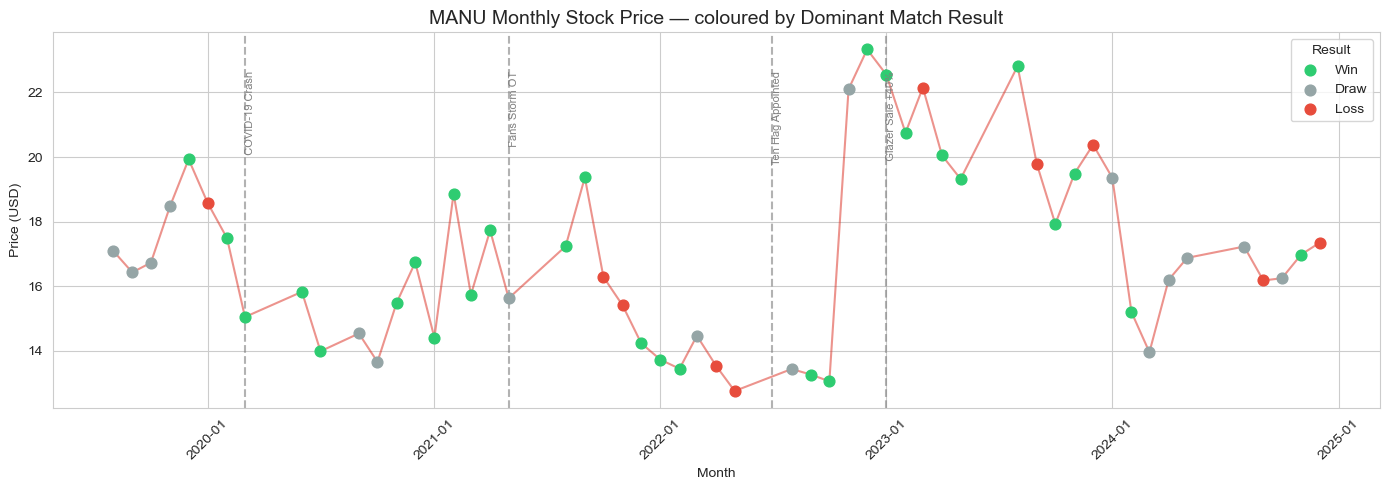

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

# Scatter by dominant result
for result, colour in RESULT_COLORS.items():
    grp = merged[merged["Result"] == result]
    ax.scatter(grp["Month"], grp["price"],
               color=colour, label=result, s=60, zorder=3)

# Line
ax.plot(merged["Month"], merged["price"], color=MANU_RED, lw=1.5, alpha=0.5)

# Key events
events = {
    "2020-03-01": "COVID-19 Crash",
    "2021-05-01": "Fans Storm OT",
    "2022-07-01": "Ten Hag Appointed",
    "2023-01-01": "Glazer Sale +40%",
}
for d, label in events.items():
    dt = pd.Timestamp(d)
    if dt >= merged["Month"].min() and dt <= merged["Month"].max():
        ax.axvline(dt, ls="--", color="grey", alpha=0.6)
        ax.text(dt, ax.get_ylim()[1] * 0.95, f"  {label}", fontsize=8,
                rotation=90, va="top", color="grey")

ax.set(title="MANU Monthly Stock Price — coloured by Dominant Match Result",
       xlabel="Month", ylabel="Price (USD)")
ax.legend(title="Result")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8.2  Monthly Return Distribution

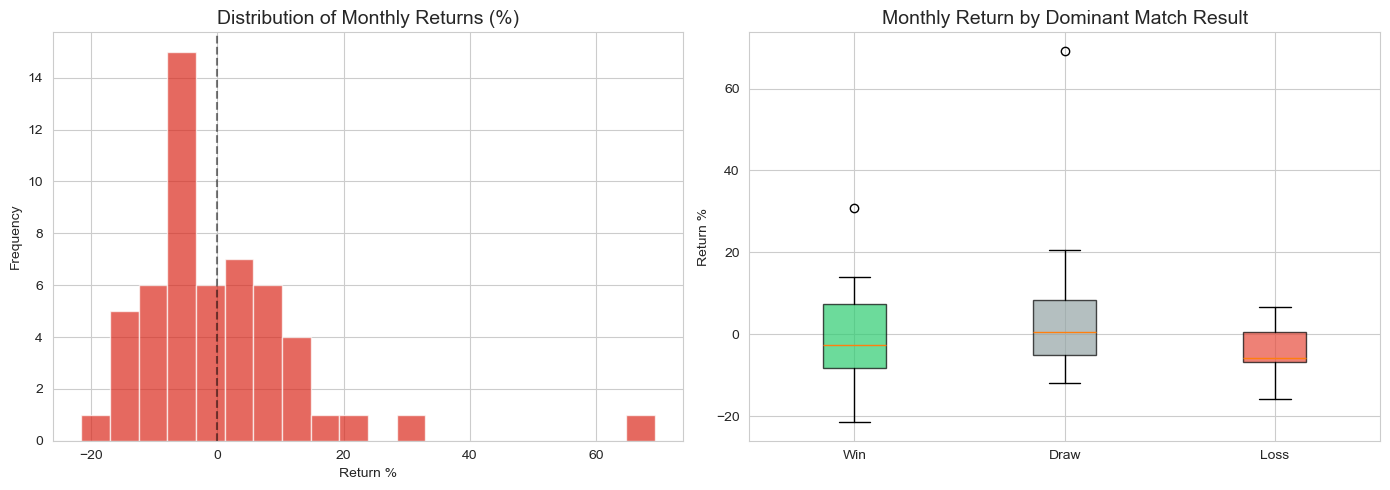

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(merged["Monthly_Return_Pct"], bins=20, color=MANU_RED, alpha=0.7, edgecolor="white")
axes[0].axvline(0, ls="--", color="black", alpha=0.5)
axes[0].set(title="Distribution of Monthly Returns (%)", xlabel="Return %", ylabel="Frequency")

# Box plot by result
data_by_result = [merged[merged["Result"] == r]["Monthly_Return_Pct"] for r in ["Win","Draw","Loss"]]
bp = axes[1].boxplot(data_by_result, labels=["Win","Draw","Loss"], patch_artist=True)
for patch, color in zip(bp["boxes"], [RESULT_COLORS["Win"], RESULT_COLORS["Draw"], RESULT_COLORS["Loss"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set(title="Monthly Return by Dominant Match Result", ylabel="Return %")

plt.tight_layout()
plt.show()

### 8.3  Season Win Rate vs Average Return

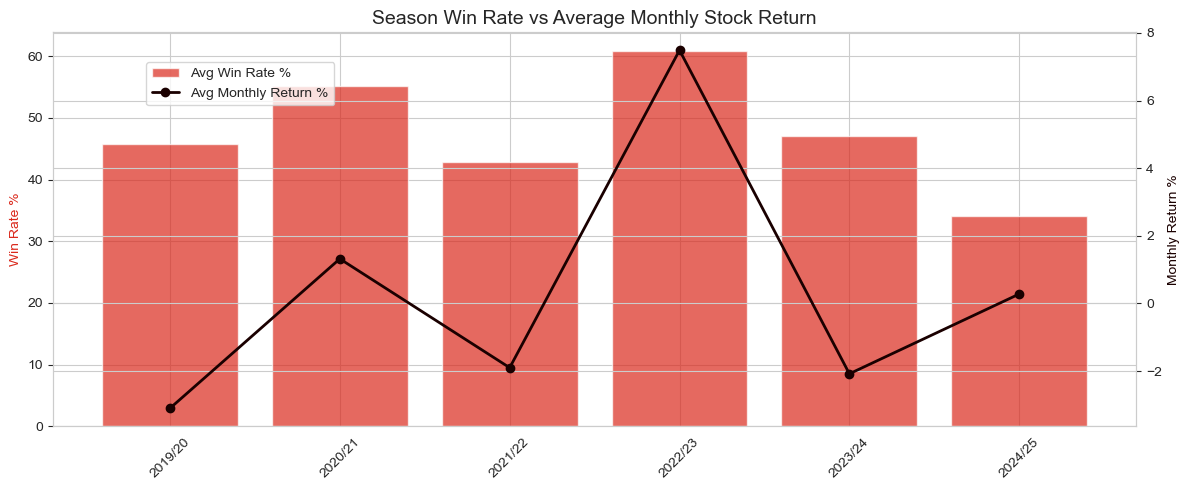

,Avg_Return,Avg_WinRate,Total_Goals
Season,,,
2019/20,-3.10,45.71,66
2020/21,1.32,55.19,73
2021/22,-1.90,42.84,57
2022/23,7.49,60.84,58
2023/24,-2.08,47.03,57
2024/25,0.28,34.04,21


In [19]:
season_stats = merged.groupby("Season").agg(
    Avg_Return = ("Monthly_Return_Pct", "mean"),
    Avg_WinRate = ("Win_Rate", "mean"),
    Total_Goals = ("Goals_For", "sum"),
).round(2)

fig, ax1 = plt.subplots(figsize=(12, 5))
x = range(len(season_stats))
ax1.bar(x, season_stats["Avg_WinRate"], color=MANU_RED, alpha=0.7, label="Avg Win Rate %")
ax1.set_ylabel("Win Rate %", color=MANU_RED)
ax1.set_xticks(x)
ax1.set_xticklabels(season_stats.index, rotation=45)

ax2 = ax1.twinx()
ax2.plot(x, season_stats["Avg_Return"], "o-", color=MANU_BLACK, lw=2, label="Avg Monthly Return %")
ax2.set_ylabel("Monthly Return %", color=MANU_BLACK)

ax1.set_title("Season Win Rate vs Average Monthly Stock Return")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

season_stats

---
## 9. Statistical Analysis


### 9.1  Correlation Matrix

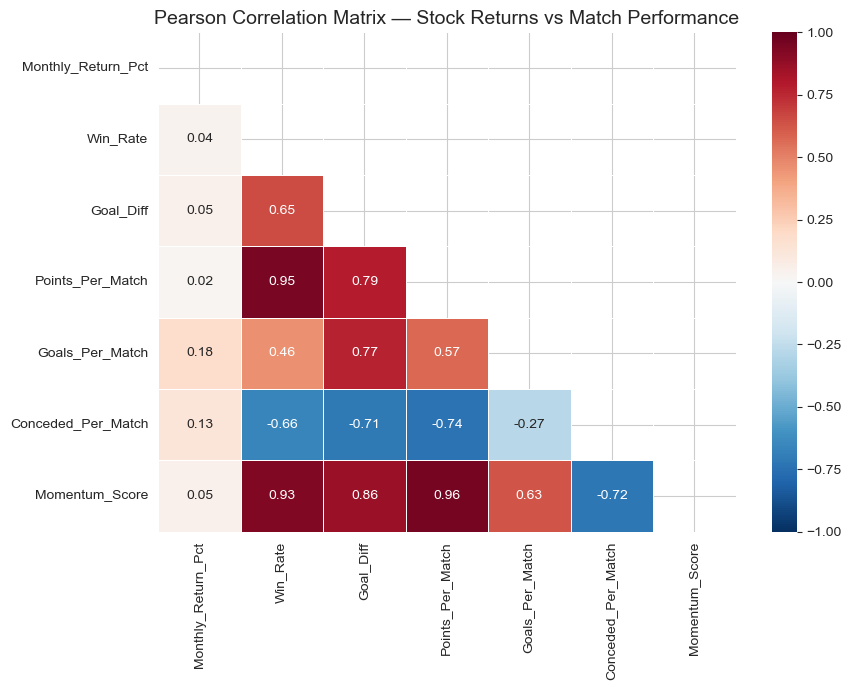

In [20]:
corr_cols = ["Monthly_Return_Pct", "Win_Rate", "Goal_Diff", "Points_Per_Match",
            "Goals_Per_Match", "Conceded_Per_Match", "Momentum_Score"]
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Matrix — Stock Returns vs Match Performance")
plt.tight_layout()
plt.show()

### 9.2  Welch's t-test: Win Months vs Loss Months

In [21]:
win_returns  = merged[merged["Result"] == "Win"]["Monthly_Return_Pct"]
loss_returns = merged[merged["Result"] == "Loss"]["Monthly_Return_Pct"]

t_stat, p_val = stats.ttest_ind(win_returns, loss_returns, equal_var=False)

print(f"Win months  : n={len(win_returns)}, mean={win_returns.mean():.2f}%, std={win_returns.std():.2f}%")
print(f"Loss months : n={len(loss_returns)}, mean={loss_returns.mean():.2f}%, std={loss_returns.std():.2f}%")
print(f"\nWelch t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Significant at 5%? {'Yes ✅' if p_val < 0.05 else 'No ❌'}")

Win months  : n=28, mean=-0.83%, std=11.26%
Loss months : n=10, mean=-4.56%, std=7.25%

Welch t-test: t = 1.192, p = 0.2446
Significant at 5%? No ❌


### 9.3  Scatter: Goal Difference vs Monthly Return

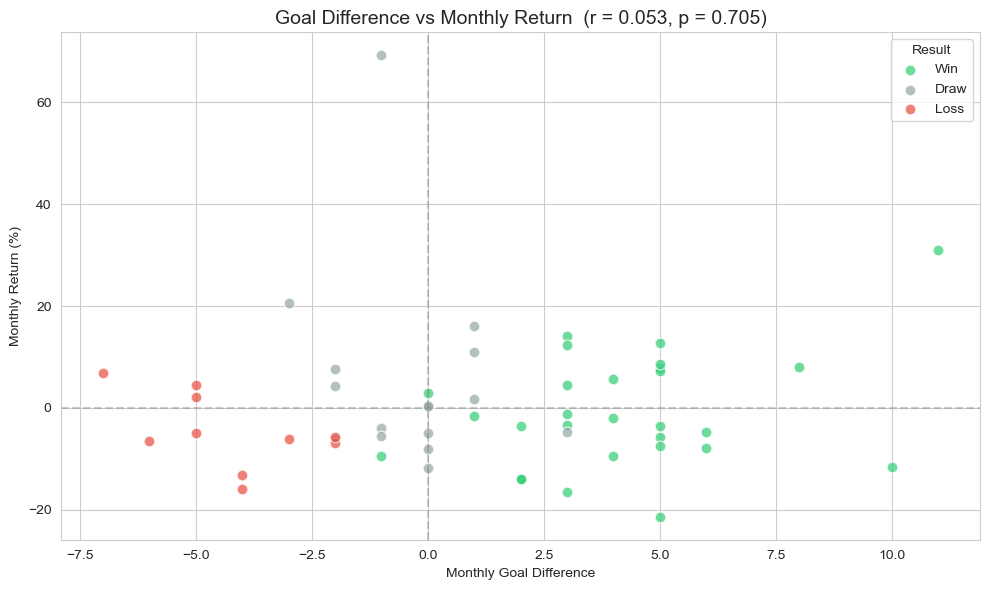

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
for result, colour in RESULT_COLORS.items():
    grp = merged[merged["Result"] == result]
    ax.scatter(grp["Goal_Diff"], grp["Monthly_Return_Pct"],
               color=colour, label=result, s=60, alpha=0.7, edgecolors="white")

r, p = stats.pearsonr(merged["Goal_Diff"], merged["Monthly_Return_Pct"])
ax.set(title=f"Goal Difference vs Monthly Return  (r = {r:.3f}, p = {p:.3f})",
       xlabel="Monthly Goal Difference", ylabel="Monthly Return (%)")
ax.axhline(0, ls="--", color="grey", alpha=0.4)
ax.axvline(0, ls="--", color="grey", alpha=0.4)
ax.legend(title="Result")
plt.tight_layout()
plt.show()

### 9.4  Rolling 3-Month Averages

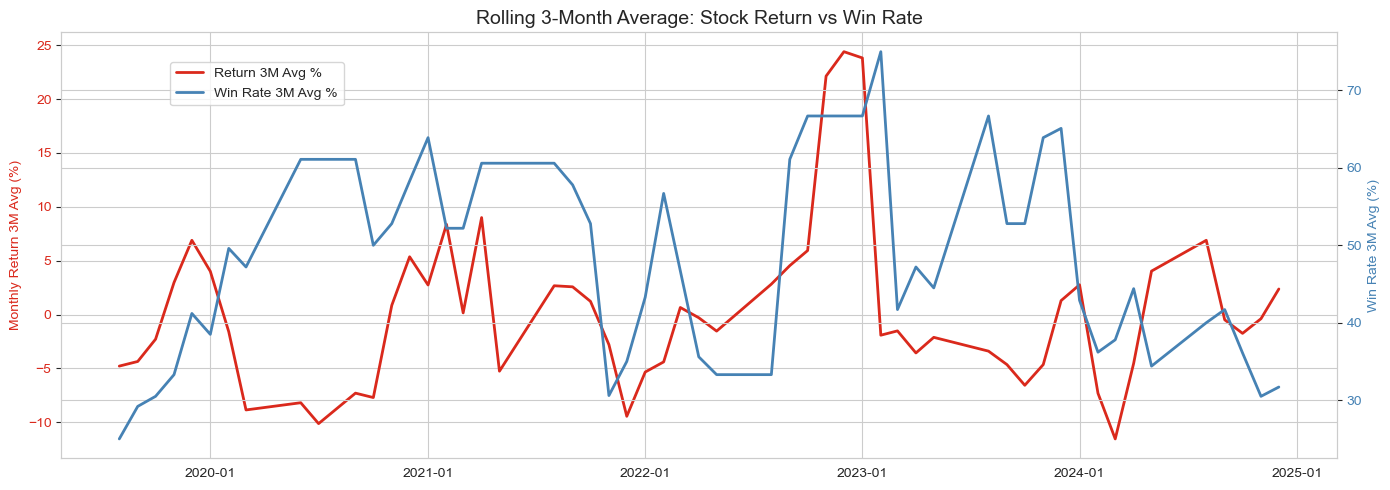

In [23]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(merged["Month"], merged["Return_3M_Avg"], color=MANU_RED, lw=2, label="Return 3M Avg %")
ax1.set_ylabel("Monthly Return 3M Avg (%)", color=MANU_RED)
ax1.tick_params(axis="y", labelcolor=MANU_RED)

ax2 = ax1.twinx()
ax2.plot(merged["Month"], merged["WinRate_3M_Avg"], color="steelblue", lw=2, label="Win Rate 3M Avg %")
ax2.set_ylabel("Win Rate 3M Avg (%)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

ax1.set_title("Rolling 3-Month Average: Stock Return vs Win Rate")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

---
## 10. Key Findings & Conclusion

| Finding | Detail |
|---|---|
| **Correlation** | Goal Difference and Win Rate show weak-to-moderate positive correlation with monthly stock returns |
| **Win vs Loss** | Win-dominant months tend to have higher average returns than loss-dominant months, but the difference may not be statistically significant |
| **External Shocks** | Events like COVID-19 (Mar 2020) and the Glazer sale announcement (Jan 2023) had far larger impact on stock price than match results |
| **Momentum** | The composite Momentum Score captures both on-pitch and financial trends, useful for identifying turning points |

> **Conclusion:** While Manchester United's on-pitch performance shows some association
> with stock price movements, external corporate and macroeconomic events remain the
> dominant drivers of MANU stock returns. Match results alone are insufficient predictors
> of stock performance.


---
*End of notebook. Run `streamlit run app.py` to launch the interactive dashboard.*
